In [ ]:
!hostname

gpue02.delta.ncsa.illinois.edu


In [2]:
import scanpy as sc
import scipy.sparse as sp
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.chdir('/projects/bgdb/asachan/methods/FIREFate/moscot')  # directory containing utils.py
import sys
import logging
import warnings

export_dir = "/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human"
out_tmp = '/projects/bgdb/asachan/tmp'

In [4]:
pd.set_option('mode.string_storage', 'python')

In [5]:
import muon as mu
# Import a module with ATAC-seq-related functions
from muon import atac as ac

/projects/bgdb/asachan/.conda/envs/moscot/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## Create LSI embeddings for ATAC data

In [8]:
atac_file = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/atac_objects/atac_fiber/atac_female_type2.h5ad'
adata_atac = sc.read_h5ad(atac_file)

In [9]:
adata_atac

AnnData object with n_obs × n_vars = 5830 × 27649
    obs: 'replicates', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'orig.ident', 'sample', 'group', 'ReadsInPeaks', 'FRIP', 'fiber_class_1_anno', 'Annotation', 'UMAP_1', 'UMAP_2', 'fiber_class_anno', 'country', 'age', 'Sex'
    var: 'n_cells'
    uns: 'Annotation_colors', 'lsi', 'neighbors', 'sample_colors', 'umap'
    obsm: 'X_UMAP', 'X_lsi', 'X_umap'
    varm: 'LSI'
    layers: 'Tn5_insertion_counts'
    obsp: 'connectivities', 'distances'

#### If X_lsi not present - create

In [37]:
# %% [3] Sanity-check that .X really holds raw Tn5 counts
X = adata.X
print(type(X), X.dtype, "nnz:", X.nnz if sp.issparse(X) else "dense",
      "max:", X.max(), "min:", X.min())
# expected: sparse int counts, max == 4

<class 'scipy.sparse._csr.csr_matrix'> int64 nnz: 23271064 max: 4 min: 0


In [38]:
# %% [5] Light peak filtering
# 265k peaks is a lot; drop ultra-rare peaks to stabilise SVD.
# Tune min_cells (e.g. 0.5%–1% of cells) — here ~30/5830 cells.
sc.pp.filter_genes(adata, min_cells=200)
adata

AnnData object with n_obs × n_vars = 5830 × 27649
    obs: 'replicates', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'orig.ident', 'sample', 'group', 'ReadsInPeaks', 'FRIP', 'fiber_class_1_anno', 'Annotation', 'UMAP_1', 'UMAP_2', 'fiber_class_anno', 'country', 'age', 'Sex'
    var: 'n_cells'
    obsm: 'X_UMAP'
    layers: 'Tn5_insertion_counts'

In [39]:
# %% [6] (Optional but standard) Binarize peak accessibility
# LSI was originally defined on binary peak×cell matrices.
# With max=4 you can either binarize or keep counts; binarizing is the
# muon/Signac default and is what the moscot tutorial effectively uses.
ac.pp.binarize(adata)          # in-place on .X
# equivalent manual: adata.X.data = np.ones_like(adata.X.data)

In [40]:
# %% [7] TF-IDF normalisation
# muon's tfidf writes the normalised matrix back into .X
ac.pp.tfidf(adata, scale_factor=1e4)

In [41]:
# %% [8] LSI = truncated SVD on TF-IDF matrix
ac.tl.lsi(adata, n_comps=50)
# Result:
#   adata.obsm["X_lsi"]      (cells × 50)
#   adata.varm["LSI"]        (peaks × 50)
#   adata.uns["lsi"]["stdev"]

In [42]:
# %% [9] Drop component 1 (it tracks sequencing depth / nFrags)
# Verify first by correlating with depth, then drop.
import pandas as pd
corr = pd.Series(
    [np.corrcoef(adata.obsm["X_lsi"][:, i], adata.obs["nFrags"])[0, 1]
     for i in range(adata.obsm["X_lsi"].shape[1])]
)
print(corr.head())   # comp 0 usually |r| > 0.7

0   -0.052178
1    0.157229
2   -0.073512
3   -0.025291
4    0.203458
dtype: float64


In [43]:
drop = corr.abs() > 0.5  # if first component is cell depth correlate, drop it
keep = ~drop.values
adata.obsm["X_lsi"]       = adata.obsm["X_lsi"][:, keep]
adata.varm["LSI"]         = adata.varm["LSI"][:, keep]
adata.uns["lsi"]["stdev"] = np.asarray(adata.uns["lsi"]["stdev"])[keep]
print("kept", keep.sum(), "components")

kept 50 components


In [44]:
# Also correlate with other QC signals — sometimes a later component captures FRIP/TSS
for col in ["nFrags", "FRIP", "TSSEnrichment", "NucleosomeRatio", "BlacklistRatio"]:
    c = np.array([np.corrcoef(adata.obsm["X_lsi"][:, i], adata.obs[col])[0, 1]
                  for i in range(adata.obsm["X_lsi"].shape[1])])
    print(f"{col:>18}  max|r|={np.abs(c).max():.2f}  argmax={np.abs(c).argmax()}")

            nFrags  max|r|=0.22  argmax=6
              FRIP  max|r|=0.37  argmax=1
     TSSEnrichment  max|r|=0.08  argmax=1
   NucleosomeRatio  max|r|=0.43  argmax=1
    BlacklistRatio  max|r|=0.12  argmax=1


In [45]:
# %% [10] Restore raw counts to .X (so the file isn't left holding TF-IDF values)
adata.X = adata.layers["Tn5_insertion_counts"].copy()

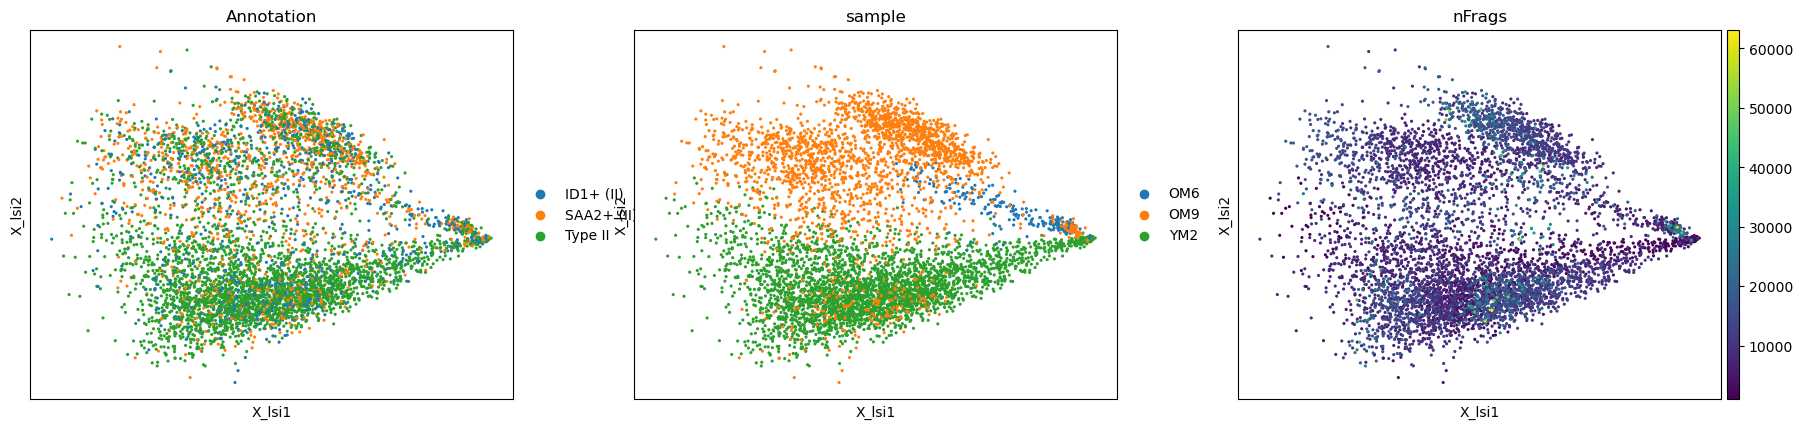

In [48]:
sc.pl.embedding(adata, "X_lsi", color=["Annotation", "sample", "nFrags"])

In [46]:
# %% [11] QC: neighbours + UMAP from LSI, compare with stored UMAP
sc.pp.neighbors(adata, use_rep="X_lsi", n_neighbors=30)
sc.tl.umap(adata)

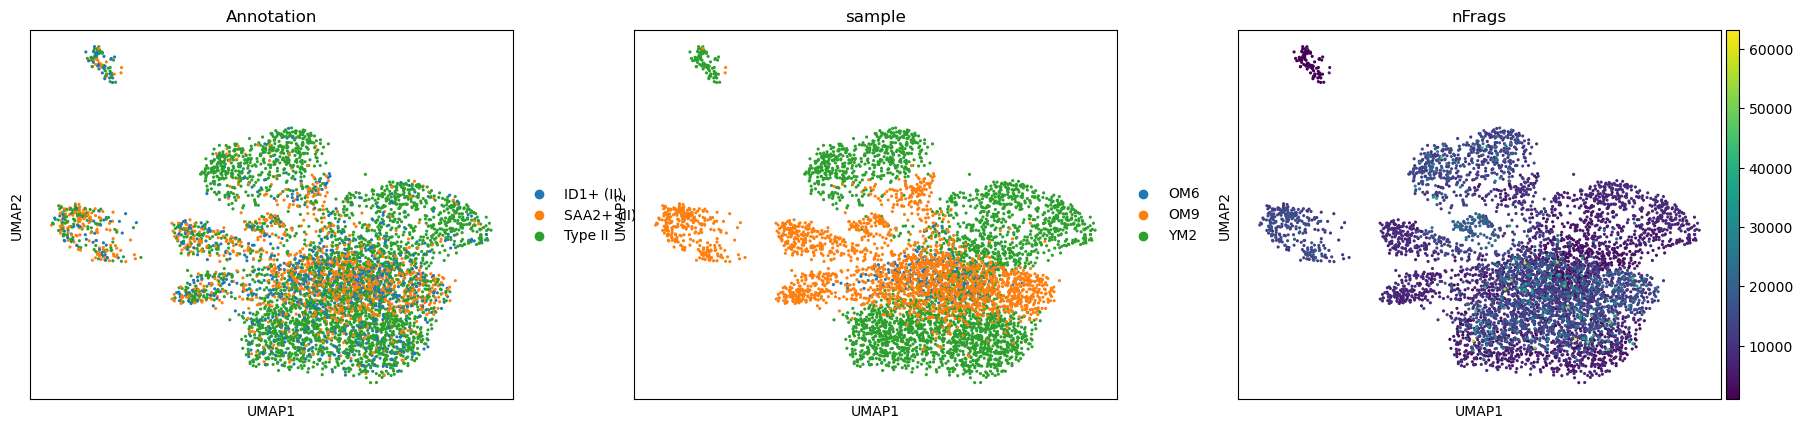

In [47]:
sc.pl.umap(adata, color=["Annotation", "sample", "nFrags"])

In [49]:
# over-write current atac file
adata.write_h5ad(atac_file)

## PCA embeddings for the RNA data

In [10]:
rna_file = '/work/hdd/bgdb/asachan/datasets_proj/SKM_ageing_human/rna_objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad'
adata_rna = sc.read_h5ad(rna_file)

In [11]:
adata_rna

AnnData object with n_obs × n_vars = 3989 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'score_aucell'
    varm: 'PCs'
    layers: 'counts', 'counts_float', 'lognorm'
    obsp: 'connectivities', 'distances'

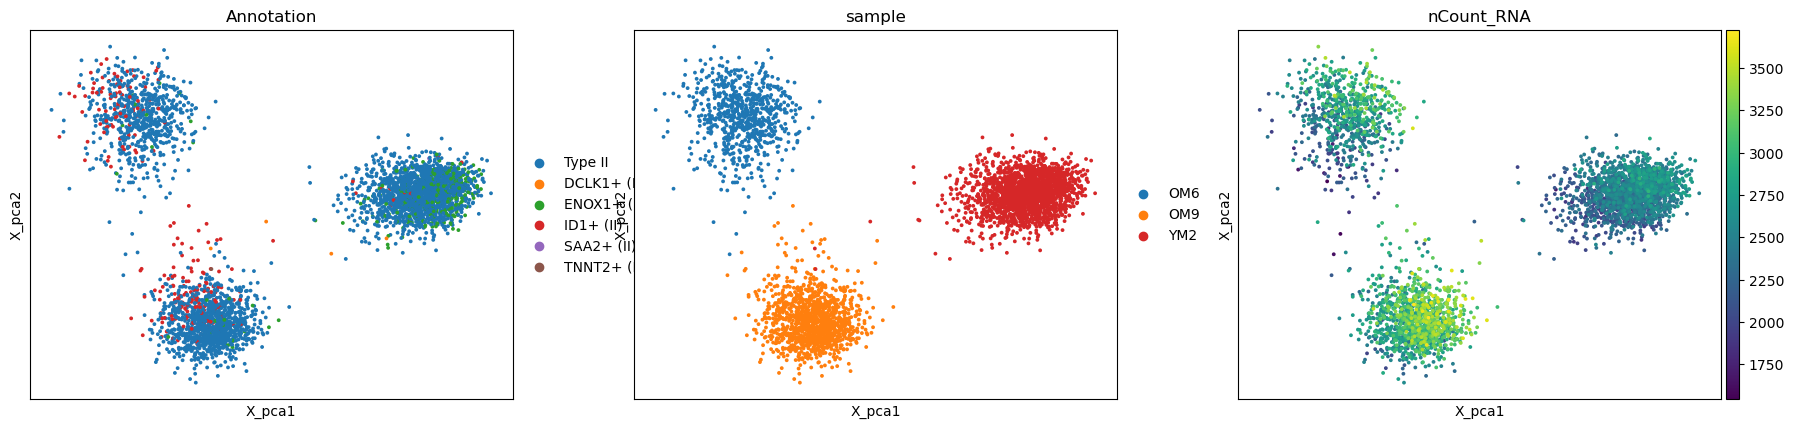

In [52]:
sc.pl.embedding(adata, "X_pca", color=["Annotation", "sample", "nCount_RNA"])

#### As we are going to make sample level/age-level GRNs - per cell noise in the OT pairings being uniform is allowed (dropping intra-sample heterogeneity for cell-cell pairing). using no joint features

# Solve quadratic Gromov-Wasserstein OT

In [23]:
import moscot
from moscot.problems.cross_modality import TranslationProblem

tp = TranslationProblem(adata_src=adata_atac, adata_tgt=adata_rna)
tp = tp.prepare(
    src_attr={"attr": "obsm", "key": "X_lsi"},
    tgt_attr={"attr": "obsm", "key": "X_pca"},
    batch_key="sample",          # one subproblem per sample → age-specific pairings
)

In [24]:
tp = tp.solve(
    epsilon=1e-3,                 # 10x smaller than what gave you the uniform plan
    alpha=1.0,
    scale_cost="mean",            # important: normalises cost matrix per sub-problem
    max_iterations=2000,          # outer GW iters
    threshold=1e-3,
    linear_solver_kwargs={        # inner Sinkhorn
        "max_iterations": 5000,
        "lse_mode": True,         # log-sum-exp: numerically stable at small epsilon
    },
)

INFO     Solving `3` problems                                                                                      
INFO     Solving problem OTProblem[stage='prepared', shape=(243, 3989)].                                           


W0430 23:41:37.973926  438646 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


INFO     Solving problem OTProblem[stage='prepared', shape=(2238, 3989)].                                          


W0430 23:41:41.002506  438646 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


INFO     Solving problem OTProblem[stage='prepared', shape=(3349, 3989)].                                          


W0430 23:41:43.657108  438646 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


In [25]:
import cloudpickle
tmp_dir = "/projects/bhdw/asachan/tmp"
with open(f'{tmp_dir}/tp_atac_rna_skm.pkl', 'wb') as f:
    cloudpickle.dump(tp, f)
print("Saved!")

Saved!


In [ ]:
import numpy as np

# check for median top-1 mass to be >0.01 and the median eff. target <1000 (non-uniform coupling - some optimal transport plan was learnt)
for key, prob in tp.problems.items():
    T = np.asarray(prob.solution.transport_matrix)
    Tn = T / T.sum(1, keepdims=True)                    # row-stochastic
    eff_k = np.exp(-(Tn * np.log(Tn + 1e-30)).sum(1))   # effective # targets per row
    top1  = Tn.max(1)
    print(f"{key}: median eff. targets/row = {np.median(eff_k):.0f}, "
          f"median top-1 mass = {np.median(top1):.3f}, "
          f"P95 top-1 = {np.percentile(top1, 95):.3f}")

('OM6', 'ref'): median eff. targets/row = 124, median top-1 mass = 0.038, P95 top-1 = 0.061
('OM9', 'ref'): median eff. targets/row = 110, median top-1 mass = 0.048, P95 top-1 = 0.253
('YM2', 'ref'): median eff. targets/row = 132, median top-1 mass = 0.043, P95 top-1 = 0.312
